In [2]:
"""SD3.5-L-Turbo Prompt-based Image Editing (4 steps)

Based on: "Exploring Multimodal Diffusion Transformers for Enhanced Prompt-based Image Editing"
"""

import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusion3Pipeline

import sys
sys.path.append("..")
from utils import (
    register_qkv_control,
    create_qkv_controller,
    p2p_callback,
    TOP5_BLOCKS,
)

pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3.5-large-turbo", torch_dtype=torch.bfloat16
).to("cuda")

/opt/conda/envs/exp-mmdit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 9/9 [00:01<00:00,  5.07it/s]


Registered 38 attention processors (SDPA: True).


100%|██████████| 4/4 [00:03<00:00,  1.26it/s]


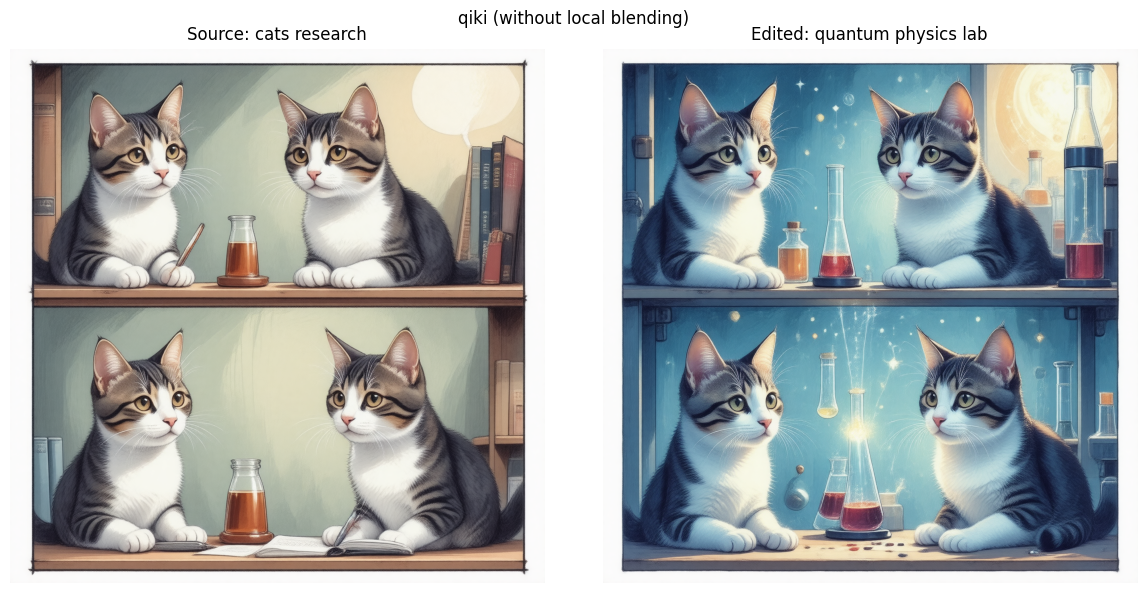

In [3]:
# Replace (qiki) - without local blending

prompts = [
    "a comic about two cats doing research", 
    "a comic about two cats doing quantum physics research in a lab full of glowing experiments"
]

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=4,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    replace_steps=0.25,  # only change at the first step (4 * 0.25 = 1)
    replace_blocks=list(range(30)), # first 30 blocks for few-step models
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=4,
    guidance_scale=0.0,  # Turbo uses no guidance
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: cats research")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: quantum physics lab")
ax[1].axis("off")
plt.suptitle("qiki (without local blending)")
plt.tight_layout()

Registered 38 attention processors (SDPA: True).


100%|██████████| 4/4 [00:03<00:00,  1.11it/s]


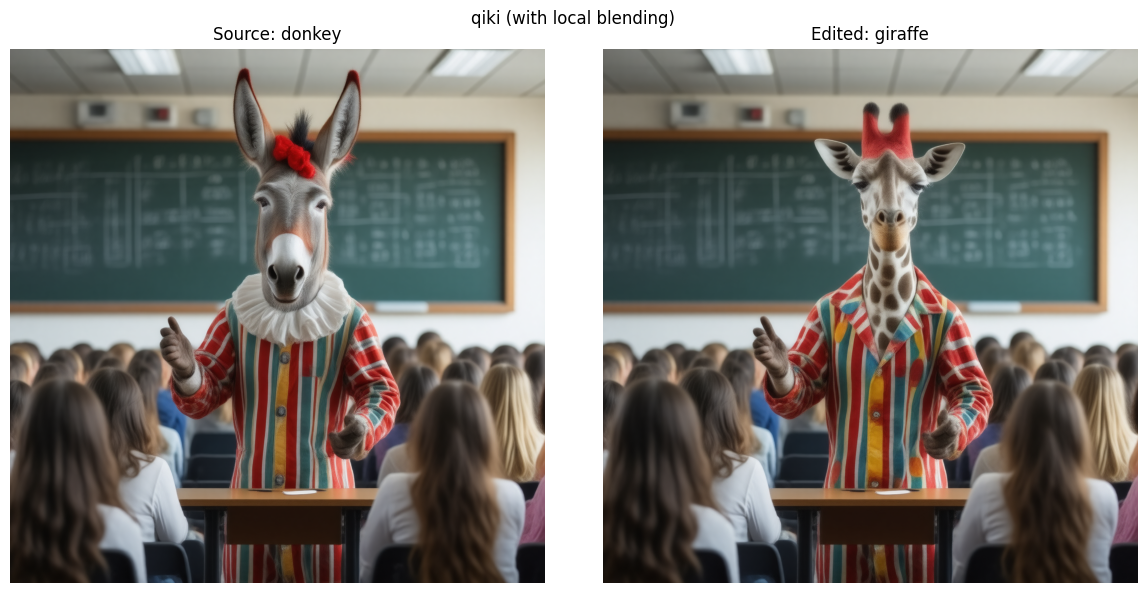

In [4]:
# Replace (qiki) - with local blending

prompts = [
    "A high resolution photo of a donkey in a clown costume giving a lecture at the front of a lecture hall. The blackboard has mathematical equations on it. There are many students in the lecture hall.",    
    "A high resolution photo of a giraffe in a clown costume giving a lecture at the front of a lecture hall. The blackboard has mathematical equations on it. There are many students in the lecture hall."
]
height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=4,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    replace_steps=0.25,  # only change at the first step (4 * 0.25 = 1)
    replace_blocks=list(range(30)), # first 30 blocks for few-step models
    local_blend_words=[["donkey"], ["giraffe"]],
    local_blend_threshold=0.3,
    aggregate_blocks=TOP5_BLOCKS["sd3.5-l-turbo"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=4,
    guidance_scale=0.0,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: donkey")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: giraffe")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Registered 38 attention processors (SDPA: True).


100%|██████████| 4/4 [00:03<00:00,  1.26it/s]


Registered 38 attention processors (SDPA: True).


100%|██████████| 4/4 [00:03<00:00,  1.25it/s]


Registered 38 attention processors (SDPA: True).


100%|██████████| 4/4 [00:03<00:00,  1.25it/s]


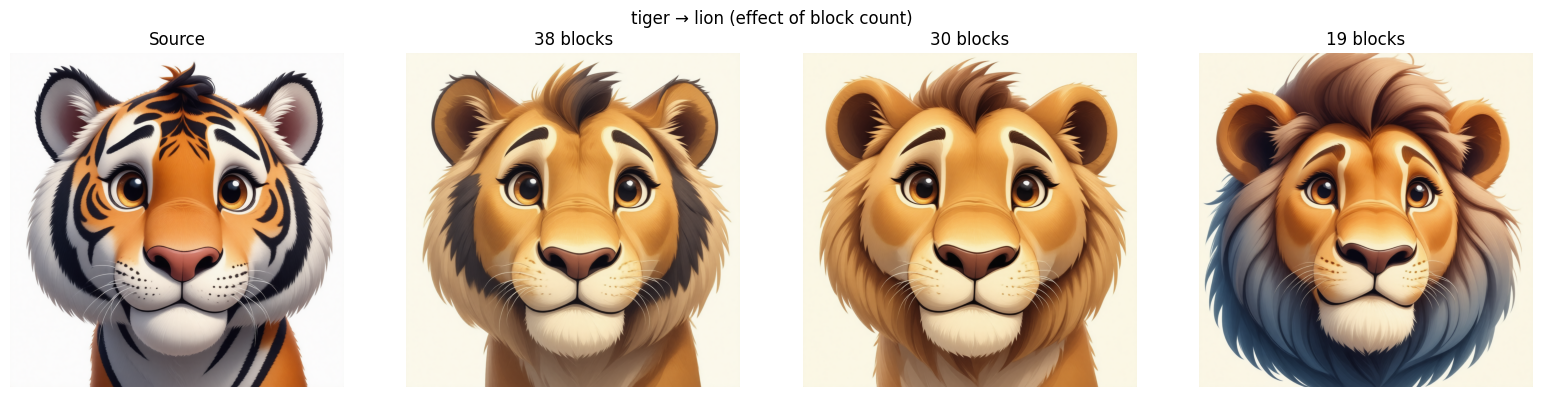

In [5]:
# Block count comparison (no local blending)
# In few-step models, replacing all 38 blocks makes the result resemble the source too much.
# We find that ~30 blocks works well for SD3.5-turbo.

prompts = ["A cartoon tiger face", "A cartoon lion face"]
height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

block_counts = [38, 30, 19]
results = {"source": None}

for n_blocks in block_counts:
    controller = create_qkv_controller(
        pipeline_type="sd3",
        prompts=prompts,
        num_inference_steps=4,
        tokenizer=tokenizers,
        device=pipe.device,
        dtype=pipe.dtype,
        method="qiki",
        replace_steps=0.25,
        replace_blocks=list(range(n_blocks)),
        t5_max_seq_len=512,
        height=height,
        width=width,
    )
    register_qkv_control(pipe, controller)
    imgs = pipe(
        prompt=prompts,
        num_inference_steps=4,
        guidance_scale=0.0,
        height=height,
        width=width,
        max_sequence_length=512,
        generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
        callback_on_step_end=p2p_callback,
        callback_on_step_end_tensor_inputs=["latents"],
    ).images
    controller.reset()
    
    if results["source"] is None:
        results["source"] = imgs[0]
    results[f"{n_blocks} blocks"] = imgs[1]

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(results["source"])
ax[0].set_title("Source")
ax[0].axis("off")
for i, n_blocks in enumerate(block_counts):
    ax[i+1].imshow(results[f"{n_blocks} blocks"])
    ax[i+1].set_title(f"{n_blocks} blocks")
    ax[i+1].axis("off")
plt.suptitle("tiger → lion (effect of block count)")
plt.tight_layout()

In [6]:
del pipe
torch.cuda.empty_cache()
print("Done!")

Done!
